# Dijkstra (Clássico vs Min-Heap) vs NetworkX — Tempo e CO₂ com CodeCarbon

**Objetivo**  
Comparar três implementações de caminhos mínimos (fonte única) em grafos ponderados não-negativos:

1) **Dijkstra Clássico (O(V²))** — sem heap;  
2) **Dijkstra com Min-Heap (`decrease_key`)** — O((V+E) log V);  
3) **Referência NetworkX** — `nx.single_source_dijkstra_path_length`.

**Protocolo experimental**  
- Tamanhos de grafo: [100, 500, 1_000, 5_000, 10_000, 50_000, 100_000] (ou até onde sua máquina suportar).  
- Para cada tamanho, repita **R = 15–20** vezes:
  - Gere `G ~ G(n, p)` com pesos inteiros positivos (1..10), garantindo conectividade (componente gigante).
  - Escolha **5 fontes aleatórias** e compute distâncias para todos os outros nós com os **3 algoritmos**.
  - Meça **Tempo (s)** e **CO₂ (kg CO₂eq)** (via CodeCarbon) de **cada execução** (algoritmo × fonte).

**Métricas e Estatística**  
- Para cada (tamanho, algoritmo): Média, Desvio-padrão, IC 95% (normal: z = 1.96).  
- **Gráficos**: linhas (tempo médio / CO₂ médio) vs número de nós, com barras de erro (IC).

**Entregáveis** (este notebook produz):  
- Tabelas **raw** e **agregadas**: `results/raw_runs.csv`, `results/aggregated.csv`;  
- Gráficos: `results/plot_time_mean_ci.png/.svg`, `results/plot_co2_mean_ci.png/.svg`;  



In [ ]:
from __future__ import annotations
from typing import List, Tuple, Dict, Optional
import random, time, math, os
import numpy as np
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt

try:
    from codecarbon import OfflineEmissionsTracker, EmissionsTracker
    HAS_CODEC = True
except Exception:
    HAS_CODEC = False

# Reprodutibilidade
GLOBAL_SEED = 42
random.seed(GLOBAL_SEED)
np.random.seed(GLOBAL_SEED)

# Pastas de saída
RESULTS_DIR = "results"
os.makedirs(RESULTS_DIR, exist_ok=True)

def now():
    return time.perf_counter()

def mean_std_ci95(series: pd.Series):
    arr = series.dropna().to_numpy()
    n = len(arr)
    if n == 0:
        return np.nan, np.nan, (np.nan, np.nan)
    mu = float(np.mean(arr))
    sd = float(np.std(arr, ddof=1)) if n > 1 else 0.0
    z = 1.96
    half = z * (sd / math.sqrt(n)) if n > 1 else 0.0
    return mu, sd, (mu - half, mu + half)


/home/marcelo/.local/lib/python3.10/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


In [2]:
class MinHeap:
    def __init__(self):
        self.heap: List[Tuple[float, int]] = []
        self.pos: Dict[int, int] = {}

    def __len__(self): return len(self.heap)

    def _swap(self, i, j):
        self.heap[i], self.heap[j] = self.heap[j], self.heap[i]
        self.pos[self.heap[i][1]] = i
        self.pos[self.heap[j][1]] = j

    def _sift_up(self, idx):
        while idx > 0:
            p = (idx - 1) // 2
            if self.heap[idx][0] < self.heap[p][0]:
                self._swap(idx, p); idx = p
            else:
                break

    def _sift_down(self, idx):
        n = len(self.heap)
        while True:
            l = 2*idx + 1; r = 2*idx + 2; s = idx
            if l < n and self.heap[l][0] < self.heap[s][0]: s = l
            if r < n and self.heap[r][0] < self.heap[s][0]: s = r
            if s != idx:
                self._swap(idx, s); idx = s
            else:
                break

    def push(self, key: float, item: int):
        if item in self.pos:
            idx = self.pos[item]
            if key < self.heap[idx][0]:
                self.decrease_key(item, key)
            return
        self.heap.append((key, item))
        idx = len(self.heap) - 1
        self.pos[item] = idx
        self._sift_up(idx)

    def pop(self) -> Tuple[float, int]:
        if not self.heap: raise IndexError("pop de heap vazio")
        root_key, root_item = self.heap[0]
        last = self.heap.pop()
        del self.pos[root_item]
        if self.heap:
            self.heap[0] = last
            self.pos[last[1]] = 0
            self._sift_down(0)
        return root_key, root_item

    def decrease_key(self, item: int, new_key: float):
        idx = self.pos.get(item)
        if idx is None:
            self.push(new_key, item); return
        old_key, _ = self.heap[idx]
        if new_key >= old_key: return
        self.heap[idx] = (new_key, item)
        self._sift_up(idx)

def _ensure_nonneg(w: float):
    if w < 0:
        raise ValueError("Dijkstra não suporta pesos negativos.")

def dijkstra_classic(adj: List[List[Tuple[int, float]]], s: int):
    # O(V^2)
    n = len(adj)
    dist = [float('inf')]*n; parent=[None]*n; vis=[False]*n
    dist[s]=0.0
    for _ in range(n):
        u=-1; best=float('inf')
        for i in range(n):
            if not vis[i] and dist[i]<best: best=dist[i]; u=i
        if u==-1: break
        vis[u]=True
        for v,w in adj[u]:
            _ensure_nonneg(w)
            if dist[u]+w<dist[v]:
                dist[v]=dist[u]+w; parent[v]=u
    return dist, parent

import heapq
def dijkstra_minheap(adj: List[List[Tuple[int, float]]], s: int):
    # O((V+E) log V) com decrease_key real
    n = len(adj)
    dist=[float('inf')]*n; parent=[None]*n
    dist[s]=0.0
    H=MinHeap()
    for v in range(n): H.push(dist[v], v)
    while len(H):
        d,u = H.pop()
        if d>dist[u]: continue
        for v,w in adj[u]:
            _ensure_nonneg(w)
            nd=d+w
            if nd<dist[v]:
                dist[v]=nd; parent[v]=u
                H.decrease_key(v, nd)
    return dist,parent


In [3]:
def ensure_connected_giant_component(G: nx.Graph) -> nx.Graph:
    if nx.is_connected(G):
        return G
    # Usa o maior componente e relabela de 0..n-1
    largest_cc = max(nx.connected_components(G), key=len)
    H = G.subgraph(largest_cc).copy()
    mapping = {old:i for i, old in enumerate(H.nodes())}
    H = nx.relabel_nodes(H, mapping)
    return H

def to_adjlist_undirected(G: nx.Graph) -> List[List[Tuple[int,float]]]:
    n = G.number_of_nodes()
    adj = [[] for _ in range(n)]
    for u,v,data in G.edges(data=True):
        w = float(data.get("weight", 1.0))
        adj[u].append((v, w))
        adj[v].append((u, w))
    return adj


In [4]:
def gen_gnp_weighted_connected(n: int, target_avg_degree: float = 10.0, seed: Optional[int] = None) -> nx.Graph:
    """
    G(n,p) com p ~= target_avg_degree/(n-1). Define pesos inteiros 1..10 (positivos).
    Garante conectividade via componente gigante (relabel).
    """
    rng = np.random.default_rng(seed)
    p = min(1.0, max(0.0, target_avg_degree / max(1, n-1)))
    G = nx.gnp_random_graph(n, p, seed=int(rng.integers(0, 2**32-1)))
    # Pesos 1..10
    for (u, v) in G.edges():
        G[u][v]["weight"] = int(rng.integers(1, 11))
    Gc = ensure_connected_giant_component(G)
    return Gc


In [ ]:
USE_OFFLINE_CARBON = False
CARBON_COUNTRY = "BRA"
MEASURE_POWER_SECS = 1
TRACKING_MODE = "process"

def _new_tracker(label: str):
    if not HAS_CODEC:
        return None
    kwargs = dict(
        project_name=label,
        output_dir=RESULTS_DIR,
        save_to_file=True,
        measure_power_secs=MEASURE_POWER_SECS,
        log_level="warning",
        tracking_mode=TRACKING_MODE,
    )
    if USE_OFFLINE_CARBON:
        return OfflineEmissionsTracker(country_iso_code=CARBON_COUNTRY, **kwargs)
    else:
        return EmissionsTracker(**kwargs)

def measure_batch(algo_name: str, callables, tracker_label: str):
    """
    Mede CO₂ e TEMPO de um conjunto de execuções (as 5 fontes) em uma só sessão do CodeCarbon.
    Retorna listas: times_sec_por_exec, co2_kg_por_exec
    O CO₂ do lote é rateado proporcionalmente ao tempo de cada execução.
    """
    tracker = _new_tracker(tracker_label)
    if tracker is not None:
        try:
            tracker.start()
        except Exception:
            tracker = None

    times = []
    for fn in callables:
        t0 = now()
        fn()
        t1 = now()
        times.append(t1 - t0)

    emissions = None
    if tracker is not None:
        try:
            emissions = tracker.stop()
        except Exception:
            emissions = None

    # Rateio do CO₂
    total_t = sum(times)
    if emissions is None:
        co2s = [np.nan] * len(times)
    elif total_t <= 0:
        co2s = [float(emissions) / max(1, len(times))] * len(times)
    else:
        co2s = [float(emissions) * (ti / total_t) for ti in times]

    return times, co2s


In [ ]:
SIZES = [100, 500, 1_000, 5_000]
REPS_PER_SIZE = 15            # 15–20 sugerido
SOURCES_PER_REP = 5
TARGET_AVG_DEGREE = 10.0
VALIDATE_SMALL = True         # valida distâncias entre algoritmos nos tamanhos pequenos
VALIDATE_UP_TO_N = 2_000

SKIP_CLASSIC_ABOVE = 10_000 


In [7]:
rows = []

for n in SIZES:
    print(f"\n=== Tamanho n={n} ===")
    for rep in range(1, REPS_PER_SIZE+1):
        seed = (GLOBAL_SEED * 1_000_003) ^ (n * 97 + rep)
        G = gen_gnp_weighted_connected(n, target_avg_degree=TARGET_AVG_DEGREE, seed=seed)
        n_eff = G.number_of_nodes()
        m_eff = G.number_of_edges()
        adj = to_adjlist_undirected(G)

        # Seleciona 5 fontes aleatórias
        rng = np.random.default_rng(seed + 12345)
        sources = list(map(int, rng.choice(n_eff, size=min(SOURCES_PER_REP, n_eff), replace=False)))

        # Validação de corretude apenas em n pequeno (uma fonte)
        if VALIDATE_SMALL and n_eff <= VALIDATE_UP_TO_N:
            src0 = sources[0]
            d_classic, _ = dijkstra_classic(adj, src0)
            d_mh, _      = dijkstra_minheap(adj, src0)
            d_nx         = nx.single_source_dijkstra_path_length(G, source=src0, weight="weight")
            d_nx_arr     = [d_nx.get(i, math.inf) for i in range(n_eff)]
            ok = np.allclose(d_classic, d_mh, atol=1e-9, equal_nan=True) and \
                 np.allclose(d_mh, d_nx_arr, atol=1e-9, equal_nan=True)
            if not ok:
                raise RuntimeError(f"Validação falhou em n={n_eff}, rep={rep}, src={src0}.")

        # === CLASSIC (em lote) ===
        if n_eff <= SKIP_CLASSIC_ABOVE:
            classic_calls = [ (lambda s=src: (dijkstra_classic(adj, s))) for src in sources ]
            t_list, co2_list = measure_batch(
                "classic",
                classic_calls,
                tracker_label=f"classic_n={n}_rep={rep}_batch",
            )
            for src, t, co2 in zip(sources, t_list, co2_list):
                rows.append({
                    "size": n, "rep": rep, "src": src,
                    "algo": "classic",
                    "time_sec": t, "co2_kg": co2,
                    "nodes": n_eff, "edges": m_eff
                })

        # === MINHEAP (em lote) ===
        minheap_calls = [ (lambda s=src: (dijkstra_minheap(adj, s))) for src in sources ]
        t_list, co2_list = measure_batch(
            "minheap",
            minheap_calls,
            tracker_label=f"minheap_n={n}_rep={rep}_batch",
        )
        for src, t, co2 in zip(sources, t_list, co2_list):
            rows.append({
                "size": n, "rep": rep, "src": src,
                "algo": "minheap",
                "time_sec": t, "co2_kg": co2,
                "nodes": n_eff, "edges": m_eff
            })

        # === NETWORKX (em lote) ===
        nx_calls = [ (lambda s=src: (nx.single_source_dijkstra_path_length(G, source=s, weight="weight"))) for src in sources ]
        t_list, co2_list = measure_batch(
            "networkx",
            nx_calls,
            tracker_label=f"networkx_n={n}_rep={rep}_batch",
        )
        for src, t, co2 in zip(sources, t_list, co2_list):
            rows.append({
                "size": n, "rep": rep, "src": src,
                "algo": "networkx",
                "time_sec": t, "co2_kg": co2,
                "nodes": n_eff, "edges": m_eff
            })

        print(f"  rep={rep:02d}  n_eff={n_eff}  m={m_eff}  fontes={len(sources)}  ✓")

raw_df = pd.DataFrame(rows)
raw_path = os.path.join(RESULTS_DIR, "raw_runs.csv")
raw_df.to_csv(raw_path, index=False)
print(f"\nSalvo: {raw_path} ({len(raw_df)} linhas)")
raw_df.head()


[codecarbon WARNING @ 15:26:55] Multiple instances of codecarbon are allowed to run at the same time.



=== Tamanho n=100 ===


[codecarbon WARNING @ 15:26:56] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 15:26:56] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 15:26:56] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 15:26:56] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 15:27:01] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 15:27:02] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 15:27:02] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 15:27:02] No CPU tracking mode found. Falling back on estimation b

  rep=01  n_eff=100  m=484  fontes=5  ✓


[codecarbon WARNING @ 15:27:14] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 15:27:14] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 15:27:14] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 15:27:14] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 15:27:18] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 15:27:19] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 15:27:19] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 15:27:19] No CPU tracking mode found. Falling back on estimation b

...

[codecarbon WARNING @ 21:39:15] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 21:39:16] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 21:39:16] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 21:39:16] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 21:39:16] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 21:39:23] Background scheduler didn't run for a long period (3s), results might be inaccurate
[codecarbon WARNING @ 21:39:23] graceful shutdown. Exceptions:
[codecarbon WARNING @ 21:39:23] <class 'Exception'>
Traceback (most recent call last):
  File "/home/marcelo/.local/lib/python3.10/site-packages/codecarbon/co

  rep=14  n_eff=4999  m=24852  fontes=5  ✓


[codecarbon WARNING @ 21:39:35] Multiple instances of codecarbon are allowed to run at the same time.
[codecarbon WARNING @ 21:39:36] We saw that you have a 12th Gen Intel(R) Core(TM) i7-1260P but we don't know it. Please contact us.
[codecarbon WARNING @ 21:39:36] We will use the default power consumption of 4 W per thread for your 16 CPU, so 64W.
[codecarbon WARNING @ 21:39:36] No CPU tracking mode found. Falling back on estimation based on TDP for CPU. 
 Linux OS detected: Please ensure RAPL files exist at /sys/class/powercap/intel-rapl/subsystem to measure CPU

[codecarbon WARNING @ 21:39:36] No CPU tracking mode found. Falling back on CPU load mode.
[codecarbon WARNING @ 21:39:43] Background scheduler didn't run for a long period (3s), results might be inaccurate
[codecarbon WARNING @ 21:39:43] graceful shutdown. Exceptions:
[codecarbon WARNING @ 21:39:43] <class 'Exception'>
Traceback (most recent call last):
  File "/home/marcelo/.local/lib/python3.10/site-packages/codecarbon/co

  rep=15  n_eff=4999  m=25172  fontes=5  ✓

Salvo: results/raw_runs.csv (900 linhas)


,size,rep,src,algo,time_sec,co2_kg,nodes,edges
0,100,1,77,classic,0.001758,3.610753e-08,100,484
1,100,1,11,classic,0.001363,2.799618e-08,100,484
2,100,1,0,classic,0.001223,2.511183e-08,100,484
3,100,1,82,classic,0.001225,2.515010e-08,100,484
4,100,1,62,classic,0.001220,2.505470e-08,100,484


In [8]:
def agg_with_ci(df: pd.DataFrame):
    out = []
    for (size, algo), g in df.groupby(["size","algo"]):
        mu_t, sd_t, (lo_t, hi_t) = mean_std_ci95(g["time_sec"])
        mu_c, sd_c, (lo_c, hi_c) = mean_std_ci95(g["co2_kg"])
        out.append({
            "size": size,
            "algo": algo,
            "n_runs": len(g),
            "time_mean": mu_t, "time_std": sd_t, "time_ci95_lo": lo_t, "time_ci95_hi": hi_t,
            "co2_mean":  mu_c, "co2_std":  sd_c, "co2_ci95_lo":  lo_c, "co2_ci95_hi":  hi_c,
            "nodes_mean": g["nodes"].mean(),
            "edges_mean": g["edges"].mean(),
        })
    return pd.DataFrame(out).sort_values(["size","algo"]).reset_index(drop=True)

agg_df = agg_with_ci(raw_df)
agg_path = os.path.join(RESULTS_DIR, "aggregated.csv")
agg_df.to_csv(agg_path, index=False)
print(f"Salvo: {agg_path}")
agg_df.head(12)


Salvo: results/aggregated.csv


,size,algo,n_runs,time_mean,time_std,time_ci95_lo,time_ci95_hi,co2_mean,co2_std,co2_ci95_lo,co2_ci95_hi,nodes_mean,edges_mean
0,100,classic,75,0.001303,0.000334,0.001228,0.001379,2.783819e-08,5.637028e-09,2.656241e-08,2.911397e-08,100.000000,488.933333
1,100,minheap,75,0.001474,0.000450,0.001372,0.001576,2.787399e-08,6.318976e-09,2.644388e-08,2.930411e-08,100.000000,488.933333
2,100,networkx,75,0.000998,0.000344,0.000920,0.001075,2.598066e-08,9.856171e-09,2.374999e-08,2.821132e-08,100.000000,488.933333
3,500,classic,75,0.016127,0.003818,0.015263,0.016991,3.188481e-08,7.186395e-09,3.025837e-08,3.351124e-08,500.000000,2503.733333
4,500,minheap,75,0.007158,0.001414,0.006838,0.007478,2.757414e-08,9.010595e-09,2.553485e-08,2.961343e-08,500.000000,2503.733333
5,500,networkx,75,0.003964,0.001059,0.003724,0.004204,2.858624e-08,6.458455e-09,2.712455e-08,3.004792e-08,500.000000,2503.733333
6,1000,classic,75,0.051144,0.005935,0.049801,0.052487,4.150650e-08,4.591660e-09,4.046731e-08,4.254569e-08,1000.000000,4988.866667
7,1000,minheap,75,0.012155,0.002894,0.011500,0.012810,3.084440e-08,7.096877e-09,2.923822e-08,3.245057e-08,1000.000000,4988.866667
8,1000,networkx,75,0.006612,0.001698,0.006228,0.006996,2.556192e-08,1.186639e-08,2.287630e-08,2.824754e-08,1000.000000,4988.866667
9,5000,classic,75,1.094348,0.270241,1.033187,1.155510,NaN,NaN,NaN,NaN,4999.733333,24987.200000


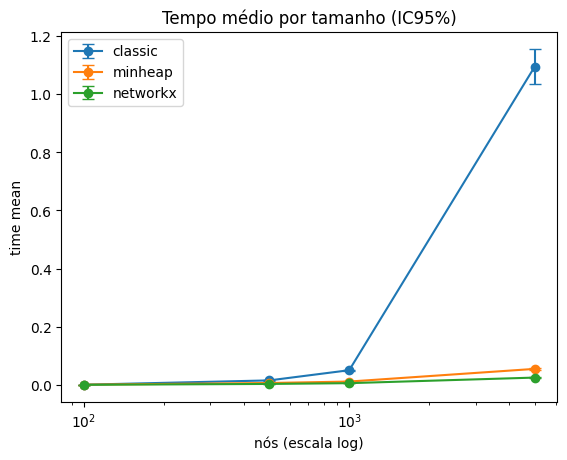

Salvo: results/plot_time_mean_ci.png e results/plot_time_mean_ci.svg


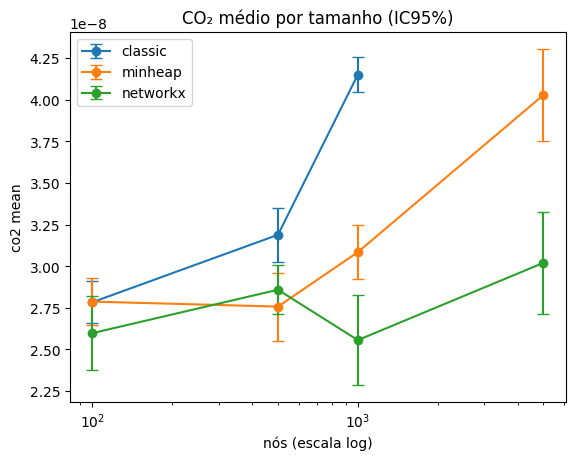

Salvo: results/plot_co2_mean_ci.png e results/plot_co2_mean_ci.svg


In [9]:
def plot_with_ci(df: pd.DataFrame, y_mean: str, y_lo: str, y_hi: str, title: str, fname: str):
    plt.figure()
    for algo, g in df.groupby("algo"):
        g2 = g.sort_values("size")
        x = g2["size"].to_numpy()
        y = g2[y_mean].to_numpy()
        lo = g2[y_lo].to_numpy()
        hi = g2[y_hi].to_numpy()
        err = np.vstack([y - lo, hi - y])
        plt.errorbar(x, y, yerr=err, marker="o", capsize=4, label=algo)
    plt.xscale("log")  # tamanhos variam muito
    plt.xlabel("nós (escala log)")
    plt.ylabel(y_mean.replace("_"," "))
    plt.title(title)
    plt.legend()
    png = os.path.join(RESULTS_DIR, f"{fname}.png")
    svg = os.path.join(RESULTS_DIR, f"{fname}.svg")
    plt.savefig(png, bbox_inches="tight")
    plt.savefig(svg, bbox_inches="tight")
    plt.show()
    print("Salvo:", png, "e", svg)

plot_with_ci(agg_df, "time_mean", "time_ci95_lo", "time_ci95_hi",
             "Tempo médio por tamanho (IC95%)", "plot_time_mean_ci")

plot_with_ci(agg_df, "co2_mean", "co2_ci95_lo", "co2_ci95_hi",
             "CO₂ médio por tamanho (IC95%)", "plot_co2_mean_ci")
